# Joint Diffusion training

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('diffusionsim')))
from tqdm import tqdm
from pathlib import Path
import time
import json
import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
import torch
from typing import Optional
import typer
from dataclasses import dataclass, asdict, field
from typing_extensions import Annotated
import pprint
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/srv/conda/envs/notebook'

In [6]:
exp_dir = "/mnt/home/ssa2206/Climsim/diffusion-climsim/experiments"

In [17]:

def define_configs():
    dl_params = tru.TrainLoaderParams()
    dl_params.batch_size = 512
    dl_params.shuffle = True
    dl_params.num_workers = 0
    dl_params.prefetch_factor = None
    dl_params.persistent_workers = False
    dl_params.multiprocessing_context = None#"forkserver"
    dl_params.pin_memory = True
    
    dconfig = tru.DataConfig()
    dconfig.dataloader_params = dl_params
    dconfig.source = "local-vzarr" # specify from raw cloud bucket
    dconfig.climsim_type = "low-res-expanded" 
    dconfig.dataset_type = "xbatch"
    dconfig.data_dir = "/mnt/home/ssa2206/Climsim/diffusion-climsim/data/local_manifests"
    dconfig.train_test_split = [1.0]
    dconfig.data_vars = "v1"

    tconfig = tru.TrainingConfig()
    tconfig.exp_id = 'climsim_training'
    tconfig.num_epochs = 5
    tconfig.phases = ['train']
    #tconfig.lr_scheduler = 'get_cosine_schedule_with_warmup'
    #tconfig.lr_warmup_steps = 100
    tconfig.learning_rate = 3e-5
    tconfig.batch_logging_interval = 32
    tconfig.batch_checkpoint_interval = 50
    tconfig.save_best_epoch = True
    tconfig.log_gradients = False
    tconfig.loss_weights = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}
    tconfig.max_T_sample = 51

    unet = tru.UNetParams()
    unet.block_out_channels = (128, 256, 512)
    unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
    unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
    unet.layers_per_block = 1
    unet.norm_num_groups = 2
    unet.in_channels = 128 if dconfig.data_vars == "v1" else 368
    unet.out_channels = unet.in_channels

    mconfig = tru.ModelConfig()
    mconfig.model_type = "ddpm_diffusion"
    mconfig.unet = unet
    mconfig.scheduler = tru.SchedulerParams()
    # define baseline model
    mconfig.bl_hidden_dims = [256, 256]
    mconfig.bl_num_layers = 2

    return(tconfig, mconfig, dconfig)

In [18]:
def setup_configs(exp_id, run_id, exp_dir, save_=False):
    from pathlib import Path
    base_dir = os.path.join(exp_dir, exp_id)
    Path(base_dir).mkdir(parents=True, exist_ok=True)
    tconfig, mconfig, dconfig = define_configs()
    tconfig.exp_id = exp_id
    if save_:
        with open(os.path.join(base_dir, f'{run_id}.json'), "w") as f:
            json.dump(dict(
                training_config=asdict(tconfig),
                model_config=asdict(mconfig),
                data_config=asdict(dconfig),
            ), f)
    return(base_dir, tconfig, mconfig, dconfig)

In [19]:
base_dir, tconfig, mconfig, dconfig = setup_configs("empire_fullrun", "trial_1", "/mnt/home/ssa2206/Climsim/diffusion-climsim/experiments")

In [21]:
model = tru.load_model_from_ckpt("trial_1-ckpt.pt", mconfig, "empire_fullrun", exp_dir)

model

/mnt/home/ssa2206/Climsim/diffusion-climsim/diffusionsim/diffusionsim/training_utils.py:173: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(c

UNet2DModel(
  (conv_in): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=128, out_features=512, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=512, out_features=512, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0): ResnetBlock2D(
          (norm1): GroupNorm(2, 128, eps=1e-05, affine=True)
          (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=512, out_features=128, bias=True)
          (norm2): GroupNorm(2, 128, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(128, 128

In [ ]:
model = tru.load_model(mconfig)
dataloaders, indices = tru.load_dataloaders(dconfig)
optimizer = tru.create_optimizer(model, tconfig)

ERROR 1: PROJ: proj_create_from_database: Open of /srv/conda/envs/notebook/share/proj failed


In [9]:
dataloaders[0].dataset.data.dims

FrozenMappingWarningOnValuesAccess({'time': 210238, 'lev': 60, 'ncol': 384})

In [17]:
images = next(iter(dataloaders[0]))

In [ ]:
loss_fn = torch.nn.MSELoss()
base_dir = "/mnt/home/ssa2206/Climsim/diffusion-climsim/experiments/empire_fullrun"
scheduler = tru.load_scheduler(mconfig)
trainer = tru.DiffusionTrainer(model, scheduler, dataloaders, loss_fn, optimizer, tconfig, base_dir=base_dir, rank=0)

Initializing trainer with rank: 0
Using device: cpu


In [11]:
trainer.train(1, log=True, run_id="trial_1")

Getting ready to train model for 1 epochs
Training for 1 epochs


{"event": "epoch start", "time": 1743064617.954384, "pid": 3925131, "epoch": 0}


{"event": "training start", "time": 1743064633.7781694, "pid": 3925131, "batch": 0}
{"event": "run-batch start", "time": 1743064634.896076, "pid": 3925131}
{"event": "run-batch end", "time": 1743064768.6834893, "pid": 3925131, "duration": 133.7874038219452}
{"event": "training end", "time": 1743064768.6847007, "pid": 3925131, "batch": 0, "duration": 134.9065272808075}


Currently at epoch 0, step 0


{"event": "training start", "time": 1743064783.0198221, "pid": 3925131, "batch": 1}
{"event": "run-batch start", "time": 1743064784.0738533, "pid": 3925131}


KeyboardInterrupt: 

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import fsspec
import os
import sys
import dask
import json
from dataclasses import dataclass, asdict, field
sys.path.append(os.path.abspath(os.path.join('../diffusionsim')))
import gcsfs
#fs = gcsfs.GCSFileSystem()

#user_path = "gs://leap-persistent/sammyagrawal"

#fs.ls(user_path)

from pprint import pprint

In [2]:
#import diffusers
import diffusionsim as diff
import diffusionsim.training_utils as tru
from diffusionsim import mydatasets as data
import diffusionsim.climsim_utils as cut
import xbatcher

Diffusers not in workspace, not all models can be loaded


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Loading Data

In [4]:
from pprint import pprint

In [9]:
dconfig = tru.DataConfig()
dconfig.source = "gcsfs" # specify from raw cloud bucket
dconfig.climsim_type = "low-res-expanded"
dconfig.dataset_type = "climsim"
dconfig.data_dir = "/mnt/lustre/columbia/ssa2206/data/ClimSim_low-res-expanded/hf_manifests/"
dconfig.train_test_split = [0.7, 0.3]

In [24]:
(train_ds, test_ds), indices = data.load_dataset(dconfig, log=True)

In [25]:
dconfig.dataloader_params.shuffle = True
dconfig.dataloader_params.batch_size = 8
#(train_dataloader, test_dataloader), indices = data.load_dataloader(dconfig, log=True)

In [26]:
train_dataloader = torch.utils.data.DataLoader(train_ds, **asdict(dconfig.dataloader_params))

In [27]:
batch = next(iter(train_dataloader))

{"event": "get-batch start", "time": 1741748941.8612232, "pid": 3999, "batch_idx": 7}
{"event": "get-batch end", "time": 1741748948.566426, "pid": 3999, "batch_idx": 7, "duration": 6.705199956893921}
{"event": "get-batch start", "time": 1741748948.5665772, "pid": 3999, "batch_idx": 84}
{"event": "get-batch end", "time": 1741748955.470571, "pid": 3999, "batch_idx": 84, "duration": 6.90399169921875}
{"event": "get-batch start", "time": 1741748955.4707136, "pid": 3999, "batch_idx": 69}
{"event": "get-batch end", "time": 1741748961.8626835, "pid": 3999, "batch_idx": 69, "duration": 6.3919677734375}
{"event": "get-batch start", "time": 1741748961.8628154, "pid": 3999, "batch_idx": 113}
{"event": "get-batch end", "time": 1741748967.991778, "pid": 3999, "batch_idx": 113, "duration": 6.128959655761719}
{"event": "get-batch start", "time": 1741748967.9919176, "pid": 3999, "batch_idx": 57}
{"event": "get-batch end", "time": 1741748974.1130352, "pid": 3999, "batch_idx": 57, "duration": 6.12111520

In [31]:
X, Y = batch
X.shape, Y.shape

(torch.Size([8, 124]), torch.Size([8, 128]))

### Via Buckets

In [7]:
dconfig = tru.DataConfig()

In [8]:
dconfig.dataset_type = "ClimsimImageDataset"
dconfig.source = "gcsfs"
dconfig.train_test_split = [0.05, 0.02]
dconfig.dataloader_params.batch_size = 256
dconfig.dataloader_params

TrainLoaderParams(batch_size=256, shuffle=False, num_workers=0, prefetch_factor=None, persistent_workers=False, multiprocessing_context=None, pin_memory=True)

In [9]:
dsi, dso = cut.load_raw_dataset(dconfig)

In [23]:
datasets, indices = data.train_test_split(dsi, dso, dconfig.train_test_split)
(dsi_train, dso_train), (dsi_test, dso_test) = datasets

In [24]:
from dask.diagnostics import ProgressBar

In [25]:
dsi_train

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 10512, lev: 60, ncol: 384)
Coordinates:
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: time, lev
Data variables:
    state_t      (time, lev, ncol) float64 2GB dask.array<chunksize=(1501, 60, 384), meta=np.ndarray>
    state_q0001  (time, lev, ncol) float64 2GB dask.array<chunksize=(1501, 60, 384), meta=np.ndarray>
    state_ps     (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
    pbuf_SOLIN   (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
    pbuf_LHFLX   (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
    pbuf_SHFLX   (time, ncol) float64 32MB dask.array<chunksize=(1501, 384), meta=np.ndarray>
Attributes:
    calendar:  NO_LEAP
    fv_nphys:  2
    ne:        4

In [33]:
with ProgressBar():
    dsi_train.load()
    dso_train.load()

[########################################] | 100% Completed | 179.45 s


In [37]:
train_ds = data.ClimsimImageDataset(dsi_train, dso_train, dconfig, log=False)
test_ds =  data.ClimsimImageDataset(dsi_test, dso_test, dconfig, log=False)

In [39]:
x, y = train_ds[0]

In [42]:
train_ds.X.

<xarray.Dataset> Size: 4GB
Dimensions:      (time: 10512, lev: 60, ncol: 384)
Coordinates:
  * ncol         (ncol) int64 3kB 0 1 2 3 4 5 6 ... 377 378 379 380 381 382 383
    lat          (ncol) float64 3kB -32.59 -35.99 -22.69 ... 45.34 45.34 40.39
    lon          (ncol) float64 3kB -39.73 -28.47 -39.56 ... 123.3 146.7 135.0
Dimensions without coordinates: time, lev
Data variables:
    state_t      (time, lev, ncol) float64 2GB 213.8 213.2 217.1 ... 265.5 275.3
    state_q0001  (time, lev, ncol) float64 2GB 1.485e-06 1.487e-06 ... 0.003757
    state_ps     (time, ncol) float64 32MB 1.011e+05 1.014e+05 ... 1.009e+05
    pbuf_SOLIN   (time, ncol) float64 32MB 0.0 0.0 0.0 0.0 ... 0.0 160.0 34.39
    pbuf_LHFLX   (time, ncol) float64 32MB 89.49 102.3 187.1 ... 96.97 14.38
    pbuf_SHFLX   (time, ncol) float64 32MB 5.66 10.92 6.692 ... 3.733 122.8 6.6
Attributes:
    calendar:  NO_LEAP
    fv_nphys:  2
    ne:        4

# Validating Train Climsim py


In [4]:
dl_params = tru.TrainLoaderParams()
dl_params.batch_size = 64
dl_params.shuffle = False
dl_params.num_workers = 8
dl_params.prefetch_factor = 6
dl_params.persistent_workers = True
dl_params.multiprocessing_context = "forkserver"

dconfig = tru.DataConfig()
dconfig.dataloader_params = dl_params
dconfig.source = "gcsfs" # specify from raw cloud bucket
dconfig.climsim_type = "low-res-expanded"
dconfig.dataset_type = "climsim"
dconfig.data_dir = "/mnt/lustre/columbia/ssa2206/data/ClimSim_low-res-expanded/hf_manifests/"
dconfig.train_test_split = [0.70, 0.30]

In [5]:
tconfig = diff.TrainingConfig()
tconfig.exp_id = 'climsim_training'
tconfig.num_epochs = 5
tconfig.phases = ['train']

#tconfig.lr_scheduler = 'get_cosine_schedule_with_warmup'
#tconfig.lr_warmup_steps = 100
tconfig.learning_rate = 3e-5
tconfig.batch_logging_interval = 32
tconfig.batch_checkpoint_interval = 50
tconfig.save_best_epoch = True
tconfig.log_gradients = False
tconfig.loss_weights = {'mse': 1.0, 'distribution': 0.0, 'diffusion': 0.0}

pprint(asdict(tconfig))

{'batch_checkpoint_interval': 50,
 'batch_logging_interval': 32,
 'betas': (0.9, 0.999),
 'clip_gradients': True,
 'diffusion_loss_noise_level': 10,
 'distributed_training': False,
 'exp_id': 'climsim_training',
 'learning_rate': 3e-05,
 'log_gradients': False,
 'loss_weights': {'diffusion': 0.0, 'distribution': 0.0, 'mse': 1.0},
 'lr_scheduler': None,
 'max_T_sample': 100,
 'num_epochs': 5,
 'optimizer': 'adam',
 'phases': ['train'],
 'push_to_hub': False,
 'save_best_epoch': True}


In [6]:

unet = tru.UNetParams()
unet.block_out_channels = (128, 256, 512)
unet.down_block_types = ("DownBlock2D", "DownBlock2D", "DownBlock2D")
unet.up_block_types = ("UpBlock2D", "UpBlock2D", "UpBlock2D")
unet.layers_per_block = 1
unet.norm_num_groups = 2

mconfig = tru.ModelConfig()
mconfig.model_type = "ddpm_diffusion"
mconfig.unet = unet
mconfig.scheduler =  tru.SchedulerParams()
# define baseline model
mconfig.bl_hidden_dims = [256, 256]
mconfig.bl_num_layers = 2



pprint(asdict(mconfig))

{'ae_hidden_dims': [64, 32, 16],
 'bl_hidden_dims': [256, 256],
 'bl_input_size': 124,
 'bl_num_layers': 2,
 'bl_output_size': 128,
 'data_vars': 'v1',
 'disable_enc_logstd_bias': True,
 'latent_dims': 16,
 'model_type': 'ddpm_diffusion',
 'num_channels': 128,
 'scheduler': {'beta_end': 0.02,
               'beta_schedule': 'linear',
               'clip_sample': False,
               'clip_sample_range': 4.0,
               'num_train_timesteps': 100},
 'scheduler_inference_steps': 100,
 'scheduler_type': 'ddpm',
 'unet': {'block_out_channels': (128, 256, 512),
          'down_block_types': ('DownBlock2D', 'DownBlock2D', 'DownBlock2D'),
          'in_channels': 128,
          'layers_per_block': 1,
          'norm_num_groups': 2,
          'out_channels': 128,
          'sample_size': (16, 24),
          'up_block_types': ('UpBlock2D', 'UpBlock2D', 'UpBlock2D')}}


In [7]:
def setup_run(tconfig, mconfig, dconfig, run_id, exp_dir="./experiments"):
    from pathlib import Path
    base_dir = os.path.join(exp_dir, tconfig.exp_id)
    Path(base_dir).mkdir(parents=True, exist_ok=True)

    with open(os.path.join(base_dir, f"{run_id}.json"), "w") as f:
        json.dump(dict(
            training_config=asdict(tconfig),
            model_config=asdict(mconfig),
            data_config=asdict(dconfig),
        ), f)


def setup_configs(exp_id, run_id, exp_dir, use_distribution_loss, use_diffusion_loss):
    from pathlib import Path
    base_dir = os.path.join(exp_dir, exp_id)
    Path(base_dir).mkdir(parents=True, exist_ok=True)
    tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id, exp_dir)
    tconfig.exp_id = exp_id
    with open(os.path.join(base_dir, f'{run_id}.json'), "w") as f:
        json.dump(dict(
            training_config=asdict(tconfig),
            model_config=asdict(mconfig),
            data_config=asdict(dconfig),
            use_distribution_loss=use_distribution_loss,
            use_diffusion_loss=use_diffusion_loss,
        ), f)
    return(base_dir, tconfig, mconfig, dconfig)

In [8]:
exp_dir="/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments"
exp_id = "climsim_training"
run_id = "trial_1_just_mse"

In [9]:
setup_run(tconfig, mconfig, dconfig, run_id, exp_dir)

In [33]:
use_distribution_loss = False
use_diffusion_loss = False

In [34]:
base_dir, tconfig, mconfig, dconfig = setup_configs(exp_id, run_id, exp_dir, use_distribution_loss, use_diffusion_loss)

In [35]:
# Example usage
model = tru.build_baseline_model(mconfig)
print(model)

Sequential(
  (0): Linear(in_features=124, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
)


In [36]:
dataloaders, indices = tru.load_dataloaders(dconfig, log=True)

In [37]:
loss_fn = torch.nn.MSELoss()
optimizer = tru.create_optimizer(model, tconfig)
rank = 0
base_dir

'/home/jovyan/Samarth/ClimsimProjectWork/diffusion-climsim/experiments/climsim_training'

In [43]:
with open(os.path.join(base_dir, f'{run_id}.json'), "r") as f:
    log = json.load(f)
log['test_indices'] = indices[1].tolist()
with open(os.path.join(base_dir, f'{run_id}.json'), "w") as f:
    json.dump(log, f)

In [23]:
ds = dataloaders[0].dataset

num_timesteps = dsi.sizes['time']
times = np.arange(num_timesteps)
np.random.shuffle(times)

In [38]:
pprint(dconfig)

DataConfig(dataset_type='climsim',
           climsim_type='low-res-expanded',
           source='gcsfs',
           data_dir='/mnt/lustre/columbia/ssa2206/data/ClimSim_low-res-expanded/hf_manifests/',
           train_test_split=[0.001, 0.0005],
           dataloader_params=TrainLoaderParams(batch_size=8,
                                               shuffle=False,
                                               num_workers=0,
                                               prefetch_factor=None,
                                               persistent_workers=None,
                                               multiprocessing_context=None,
                                               pin_memory=True),
           xarr_subsamples=[36, 210240, 144],
           data_vars='v1',
           use_tendencies=False,
           norm_info='image',
           prenormalize=False,
           chunksize={},
           log_batching=True)


In [40]:
x, y = next(iter(dataloaders[0]))

{"event": "get-batch start", "time": 1741760588.1860843, "pid": 8214, "batch_idx": 0}
{"event": "get-batch end", "time": 1741760591.2322328, "pid": 8214, "batch_idx": 0, "duration": 3.0461459159851074}
{"event": "get-batch start", "time": 1741760591.2323673, "pid": 8214, "batch_idx": 1}
{"event": "get-batch end", "time": 1741760594.5629475, "pid": 8214, "batch_idx": 1, "duration": 3.330577850341797}
{"event": "get-batch start", "time": 1741760594.563103, "pid": 8214, "batch_idx": 2}
{"event": "get-batch end", "time": 1741760597.7133727, "pid": 8214, "batch_idx": 2, "duration": 3.1502673625946045}
{"event": "get-batch start", "time": 1741760597.7135065, "pid": 8214, "batch_idx": 3}
{"event": "get-batch end", "time": 1741760600.7926874, "pid": 8214, "batch_idx": 3, "duration": 3.07917857170105}
{"event": "get-batch start", "time": 1741760600.7928376, "pid": 8214, "batch_idx": 4}
{"event": "get-batch end", "time": 1741760603.9410121, "pid": 8214, "batch_idx": 4, "duration": 3.148172378540

In [44]:
model(x).shape, y.shape

(torch.Size([8, 128]), torch.Size([8, 128]))

In [45]:
trainer = tru.ClimsimTrainer(model, dataloaders, loss_fn, optimizer, 
                   tconfig, base_dir, use_distribution_loss, use_diffusion_loss, rank=0)


Using device: cuda:0


In [50]:
trainer.current_run_id

''

In [46]:
trainer._run_epoch(1, phase='train')

{"event": "get-batch start", "time": 1741760799.997574, "pid": 8214, "batch_idx": 0}
{"event": "get-batch end", "time": 1741760803.2065015, "pid": 8214, "batch_idx": 0, "duration": 3.2089247703552246}
{"event": "get-batch start", "time": 1741760803.2066512, "pid": 8214, "batch_idx": 1}
{"event": "get-batch end", "time": 1741760806.158353, "pid": 8214, "batch_idx": 1, "duration": 2.95169997215271}
{"event": "get-batch start", "time": 1741760806.1584926, "pid": 8214, "batch_idx": 2}
{"event": "get-batch end", "time": 1741760809.588055, "pid": 8214, "batch_idx": 2, "duration": 3.4295597076416016}
{"event": "get-batch start", "time": 1741760809.5881932, "pid": 8214, "batch_idx": 3}
{"event": "get-batch end", "time": 1741760812.8452556, "pid": 8214, "batch_idx": 3, "duration": 3.2570600509643555}
{"event": "get-batch start", "time": 1741760812.8454163, "pid": 8214, "batch_idx": 4}
{"event": "get-batch end", "time": 1741760815.8979738, "pid": 8214, "batch_idx": 4, "duration": 3.0525548458099

Currently at epoch 1, step 0


{"event": "get-batch end", "time": 1741760828.8164392, "pid": 8214, "batch_idx": 8, "duration": 2.891697883605957}
{"event": "get-batch start", "time": 1741760828.81657, "pid": 8214, "batch_idx": 9}
{"event": "get-batch end", "time": 1741760832.467114, "pid": 8214, "batch_idx": 9, "duration": 3.650541067123413}
{"event": "get-batch start", "time": 1741760832.4672418, "pid": 8214, "batch_idx": 10}
{"event": "get-batch end", "time": 1741760835.7968595, "pid": 8214, "batch_idx": 10, "duration": 3.3296151161193848}
{"event": "get-batch start", "time": 1741760835.7969828, "pid": 8214, "batch_idx": 11}
{"event": "get-batch end", "time": 1741760838.8476906, "pid": 8214, "batch_idx": 11, "duration": 3.0507051944732666}
{"event": "get-batch start", "time": 1741760838.847814, "pid": 8214, "batch_idx": 12}
{"event": "get-batch end", "time": 1741760842.0412152, "pid": 8214, "batch_idx": 12, "duration": 3.1933984756469727}
{"event": "get-batch start", "time": 1741760842.041349, "pid": 8214, "batch_

KeyboardInterrupt: 

# Playground

## Standard Training Pipeline (no diffusion)

In [54]:
loss_fn = nn.MSELoss()

In [58]:
tconfig = tru.TrainingConfig()
tconfig.num_epochs = 10
tconfig.learning_rate = 0.0005
tconfig.batch_checkpoint_interval = 5

In [59]:
exp_id = "JointTraining"
tconfig.log_id = os.path.join("experiments", exp_id)
tconfig.ckpt_id = os.path.join(tconfig.log_id, "vanilla.pt")

In [60]:
tconfig.ckpt_id

'experiments/JointTraining/vanilla.pt'

In [32]:
def evaluate(model):
    model.eval()
    with torch.no_grad():
        total_loss = loss_fn(model(test_ds.X), test_ds.Y)
        return(total_loss / test_ds.Y.shape[0])

In [61]:
def vanilla_train(model, dataset, loss_fn, tconfig):
    dataloader = torch.utils.data.DataLoader(dataset, **asdict(dconfig.dataloader_params))
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        for x, y in dataloader:
            #x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
    
        # Print training progress
        average_loss = running_loss / len(dataloader)
        test_loss = evaluate(model).item()
        print(f'Epoch [{epoch}/{tconfig.num_epochs}], Train Loss: {average_loss:.4f}, Test Loss: {test_loss:.4f}')
        losses['train'].append(average_loss); losses['test'].append(test_loss);
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

In [62]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [35]:
evaluate(model)

tensor(0.0110, device='cuda:0')

In [63]:
model, losses = vanilla_train(model, train_ds, loss_fn, tconfig)

Epoch [1/10], Train Loss: 0.0505, Test Loss: 0.0336
Epoch [2/10], Train Loss: 0.0204, Test Loss: 0.0393
Epoch [3/10], Train Loss: 0.0180, Test Loss: 0.0469
Epoch [4/10], Train Loss: 0.0170, Test Loss: 0.0483
Epoch [5/10], Train Loss: 0.0164, Test Loss: 0.0500
Saving Model
Epoch [6/10], Train Loss: 0.0160, Test Loss: 0.0531
Epoch [7/10], Train Loss: 0.0158, Test Loss: 0.0555
Epoch [8/10], Train Loss: 0.0155, Test Loss: 0.0577
Epoch [9/10], Train Loss: 0.0154, Test Loss: 0.0591
Epoch [10/10], Train Loss: 0.0152, Test Loss: 0.0607
Saving Model


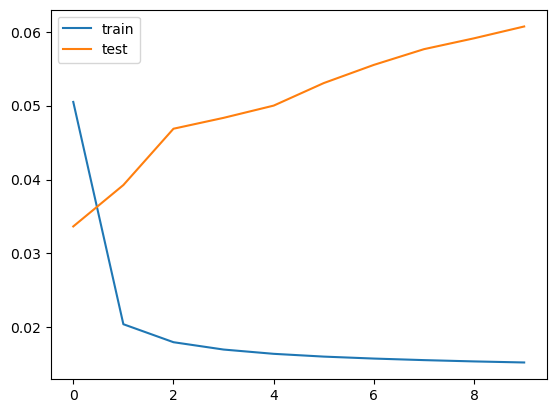

In [64]:
plt.plot(losses['train'], label='train')
plt.plot(losses['test'], label='test')
plt.legend()
plt.show()

## Diffusion Augmented training

In [33]:
exp_id = "full_dataset_testrun"
base_dir = os.path.join("experiments", exp_id)
run_id = "trial_1b"
tconfig, mconfig, dconfig = tru.load_config(run_id, exp_id)


TrainLoaderParams(batch_size=256, shuffle=True, num_workers=8, prefetch_factor=4, persistent_workers=True, multiprocessing_context='forkserver', pin_memory=True)

In [7]:
ddpm = tru.load_model_from_ckpt(f"{run_id}-ckpt.pt", mconfig, exp_id).to(device)
mconfig.scheduler_type = "ddim"
scheduler = data.load_scheduler(mconfig)
scheduler.set_timesteps(num_inference_steps=mconfig.scheduler_inference_steps)
ddpm.device

device(type='cuda', index=0)

In [8]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [49]:
%%time
x, y = train_ds[0]

CPU times: user 505 ms, sys: 775 ms, total: 1.28 s
Wall time: 1.18 s


In [52]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [14]:
y_hat = model(x.to(device))

In [15]:
def construct_image(ytensor):
    # more complex in actual setup
    return(torch.transpose(ytensor, 1, 2).reshape(-1, 128, 16, 24))

In [103]:
loss_fn = nn.MSELoss()
def image_loss(y, yhat, T: int, unet=ddpm, scheduler=scheduler):
    y, yhat = construct_image(y), construct_image(yhat)
    def encode(sample):
        eps = torch.randn(sample.shape, device=device) # BS x C x H x W
        xt = scheduler.add_noise(sample, eps, torch.LongTensor([T])) # noisy image
        return(xt)
    def decode(xt):
        for t in range(T, 0, -1):
            with torch.no_grad():
                eps_theta = unet(xt, t).sample
            xt = scheduler.step(eps_theta, t, xt).prev_sample
        return(xt)
    yhat = decode(encode(yhat))
    return(loss_fn(y, yhat))

In [54]:
image_loss(y.to(device), y_hat, 25)

tensor(1.4329, device='cuda:0', grad_fn=<MseLossBackward0>)

In [62]:
4204/256

16.421875

In [69]:
tconfig.num_epochs

20

In [72]:

len(test_ds)

8

In [80]:
%%time
c, d = train_ds[5]

CPU times: user 437 ms, sys: 1.85 ms, total: 438 ms
Wall time: 402 ms


In [81]:
%%time
loss_fn(model(a.to(device)), b.to(device))

CPU times: user 29.9 ms, sys: 0 ns, total: 29.9 ms
Wall time: 29.5 ms


tensor(0.9858, device='cuda:0', grad_fn=<MseLossBackward0>)

In [76]:
def evaluate_diff(model):
    loss = 0.0
    model.eval()
    with torch.no_grad():
        for idx in range(len(test_ds)):
            print(idx, end=" ")
            x, y = test_ds[idx]
            x, y = x.to(device), y.to(device)
            loss += loss_fn(model(x), y).item()
    return(loss / len(test_ds))

In [107]:
scheduler.timesteps

tensor([99, 98, 97, 96, 95, 94, 93, 92, 91, 90, 89, 88, 87, 86, 85, 84, 83, 82,
        81, 80, 79, 78, 77, 76, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64,
        63, 62, 61, 60, 59, 58, 57, 56, 55, 54, 53, 52, 51, 50, 49, 48, 47, 46,
        45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28,
        27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,
         9,  8,  7,  6,  5,  4,  3,  2,  1,  0])

In [121]:
def diffusion_train(model, dataset, loss_fn, tconfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=tconfig.learning_rate, weight_decay=1e-4)
    losses = dict(train=[], diffusion=[], test=[])
    for epoch in range(1, tconfig.num_epochs+1):
        model.train()  # Set the model to training mode
        pixel_loss, img_loss = 0.0, 0.0
        for idx in range(len(dataset)):
            print(idx, end=" ")
            x, y = dataset[idx]
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(x)
            ploss = loss_fn(y, y_hat)
            iloss = image_loss(y, y_hat, T=25)
            (ploss + iloss).backward()
            optimizer.step()
            pixel_loss += ploss.item(); img_loss += iloss.item()
            losses['train'].append(ploss.item()); losses['diffusion'].append(iloss.item());
        # Print training progress
        #average_loss = running_loss / len(dataloader)
        #test_loss = evaluate(model).item()
        print(f'\nEpoch [{epoch}/{tconfig.num_epochs}], Pixel Loss: {pixel_loss/len(dataset):.4f}, Image Loss: {img_loss/len(dataset):.4f}')
        
        if(epoch % tconfig.batch_checkpoint_interval == 0):
            print("Saving Model")
            torch.save(model.state_dict(), tconfig.ckpt_id)

    return(model, losses)

In [116]:
model = nn.Sequential(
    nn.Linear(in_features=124, out_features=256),
    nn.ReLU(),
    nn.Linear(in_features=256, out_features=128),
).to(device)

In [122]:
loss_fn(model(x.to(device)), y.to(device))

tensor(1.3941, device='cuda:0', grad_fn=<MseLossBackward0>)

In [123]:
x, y = train_ds[0]

In [127]:
model, losses = diffusion_train(model, train_ds, loss_fn, tconfig)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [1/10], Pixel Loss: 1.0640, Image Loss: 1.0884
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [2/10], Pixel Loss: 1.0268, Image Loss: 1.0556
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [3/10], Pixel Loss: 0.9956, Image Loss: 1.0274
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [4/10], Pixel Loss: 0.9671, Image Loss: 1.0011
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [5/10], Pixel Loss: 0.9403, Image Loss: 0.9758
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [6/10], Pixel Loss: 0.9146, Image Loss: 0.9515
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [7/10], Pixel Loss: 0.8901, Image Loss: 0.9280
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [8/10], Pixel Loss: 0.8668, Image Loss: 0.9055
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [9/10], Pixel Loss: 0.8446, Image Loss: 0.8840
0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 
Epoch [10/10], Pixel Loss: 0.8236, Image Loss: 0.8637


In [130]:
torch.save(model.state_dict(), "experiments/JointTraining/diffusion_train.pt")

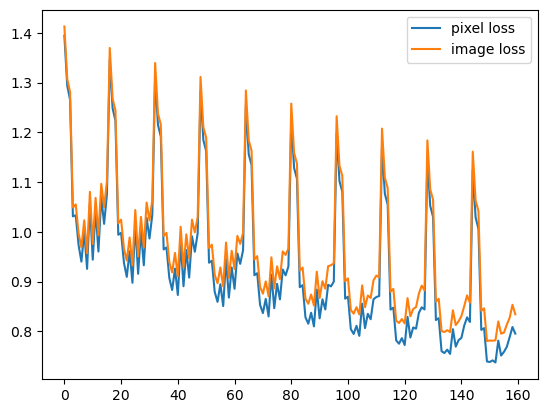

In [134]:
plt.plot(losses['train'], label='pixel loss')
plt.plot(losses['diffusion'], label='image loss')
plt.legend()
plt.show()

In [137]:
import json

In [139]:
with open("experiments/JointTraining/diffusion_train_losses.json", "w") as file:
    json.dump(losses, file)